# Mean Surface Temperature

Historical analysis of mean surface air temperature at the selected GHCN station. Covers annual means, reference-period anomalies and ENSO modulation (ONI).

**Indicator:** annual mean temperature (`TMEAN = (TMAX + TMIN) / 2`) expressed relative to the WMO 1961–1990 reference period.

```{glue:figure} trend_fig
:scale: 50%
:align: right
```

**Figure. Annual mean temperature anomalies relative to 1961–1990 climatology.** Coloured dots mark the 10 warmest years on record (absolute values on the right axis). A solid black line indicates a statistically significant trend (p < 0.05); a dashed line indicates a non-significant trend.

In [1]:
# CIndRA notebook display standard
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
})

## Setup

Import libraries and helper functions. Shared plotting utilities come from the [indicators_setup](https://github.com/lauracagigal/indicators_setup) repository; site configuration and output helpers come from `functions/air_temp.py`.

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os.path as op
import sys
import contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import plotly.io as pio
pio.renderers.default = "notebook_connected"

from myst_nb import glue 

sys.path.append("../../../../../../indicators_setup")
from ind_setup.plotting_int import plot_timeseries_interactive, fig_int_to_glue
from ind_setup.plotting import plot_bar_probs, fontsize

sys.path.append("../../../../functions")
from data_downloaders import GHCN, download_oni_index
from air_temp import (
    load_site_config,
    site_config_filename,
    list_available_sites,
    build_site_tag,
    build_output_filename,
    build_site_figures_dir,
    persist_mean_temperature_outputs,
)

from ind_setup.plotting_int import plot_oni_index_th
from ind_setup.plotting import plot_bar_probs_ONI, add_oni_cat

### Define location and variables of interest

Set `site_key` to one of the sites already configured with [`../00_site_setup.ipynb`](../00_site_setup.ipynb) (see the list printed below). The notebook loads coordinates, station ID, reference period and paths from `data/sites/<site_key>.json` — the filename is resolved with `site_config_filename()`, the same helper `00_site_setup.ipynb` uses to save it, so any site name (accents, spaces, capitals) resolves consistently.

In [4]:
sites_dir = Path('../../../../data/sites')
available_sites = list_available_sites(sites_dir)
print(f"{len(available_sites)} site(s) already configured in {sites_dir}:")
display(available_sites)

6 site(s) already configured in ../../../../data/sites:


,site_key,site_name,country,ghcn_station_id,ghcn_station_name,vars_interest
0,cook_islands_new_zealand_cwm00091843,cook_islands_new_zealand_CWM00091843,Cook Islands [New Zealand],CWM00091843,RAROTONGA INTL GSN 91843,"[TMIN, TMAX, PRCP]"
1,marshall_islands_rmw00040604,marshall_islands_RMW00040604,Marshall Islands,RMW00040604,MH KWAJALEIN GSN 91366,"[TMIN, TMAX, PRCP]"
2,marshall_islands_rmw00040710,marshall_islands_RMW00040710,Marshall Islands,RMW00040710,MH MAJURO WBAS AP GSN 91376,"[TMIN, TMAX, PRCP]"
3,niue_new_zealand_nem00091824,niue_new_zealand_NEM00091824,Niue [New Zealand],NEM00091824,HANAN AIRPORT GSN 91824,"[TMIN, TMAX, PRCP]"
4,palau,Palau,Palau,None,None,None
5,palau_psw00040309,palau_PSW00040309,Palau,PSW00040309,PW KOROR GSN 91408,"[TMIN, TMAX, PRCP]"


In [5]:
site_key = "palau_psw00040309"  # pick a site_key from the table printed above

site_config_path = sites_dir / site_config_filename(site_key)
site_cfg = load_site_config(site_config_path)

site_name = site_cfg.get('site_name', 'Site')
site_lon = float(site_cfg['site_lon'])
site_lat = float(site_cfg['site_lat'])
country = site_cfg['country']
ghcn_station_id = site_cfg['ghcn_station_id']
ghcn_station_name = site_cfg.get('ghcn_station_name', '')
vars_interest = list(site_cfg.get('vars_interest', ['TMIN', 'TMAX']))
ref_start = str(site_cfg.get('reference_period_start', '1961'))
ref_end = str(site_cfg.get('reference_period_end', '1990'))

### Get Data

Load the cached daily temperature series from `data/air_temp/GHCN_<station_id>.pkl`. All download and quality-control steps were completed in [`../00_site_setup.ipynb`](../00_site_setup.ipynb).

In [6]:
data_base_dir = Path('../../../../data')
site_figures_dir = build_site_figures_dir(Path('../../../../outputs'), site_name, site_lon, site_lat)
data_dir = Path(data_base_dir, 'air_temp')
output_dir = data_base_dir

output_dir.mkdir(exist_ok=True)
data_dir.mkdir(exist_ok=True)

path_data = str(data_dir)

### Observations from Station

Daily minimum and maximum temperature records for the GHCN station defined in the site configuration.

[GHCN-Daily documentation](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/doc/GHCND_documentation.pdf)

The data used for this analysis comes from the [GHCN-Daily](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/) database (NOAA NCEI).

GHCN-Daily provides historical daily climate records over global land areas. Records from numerous sources are merged and subjected to quality-assurance reviews. The variables used here are **`TMIN`** and **`TMAX`** (daily minimum and maximum temperature, °C), with **`TMEAN`** derived as `(TMAX + TMIN) / 2`.

**Data loading:** this notebook reads the pre-processed pickle created by [`../00_site_setup.ipynb`](../00_site_setup.ipynb). It does **not** re-download from NOAA.

**Outputs:** figures → `outputs/figures/<site_tag>/`; tables and JSON → `outputs/tables/<site_tag>/`.

Load the cached pickle, keep a daily copy for ENSO / monthly joins, then aggregate to annual means for the indicator plots below.

In [7]:
pickle_path = op.join(path_data, f'GHCN_{ghcn_station_id}.pkl')
st_data = pd.read_pickle(pickle_path)
print(f'Loaded {len(st_data)} daily records from {pickle_path}')

Loaded 25966 daily records from ../../../../data/air_temp/GHCN_PSW00040309.pkl


In [8]:
st_data_daily = st_data.copy()

In [9]:
st_data = st_data.resample('YE').mean()
glue("n_years", len(np.unique(st_data.index.year)), display=False)
glue("start_year", st_data.dropna().index[0].year, display=False)
glue("end_year", st_data.dropna().index[-1].year, display=False)

## Analysis

All indicators below are computed from the loaded daily temperature series. Linear trends are estimated with `plot_bar_probs` / `plot_timeseries_interactive` from `indicators_setup`.

### Annual mean temperature

Interactive and static plots of annual mean temperature (`TMEAN`) with a fitted linear trend. Saved under `outputs/figures/<site_tag>/` (e.g. `F2_ST_Mean_<site_tag>.png`).

In [10]:
dict_plot = [{'data' : st_data, 'var' : 'TMEAN', 'ax' : 1, 'label' : 'TMEAN'},
        ]

In [11]:
dict_plot = [{'data' : st_data, 'var' : 'TMEAN', 'ax' : 1, 'label' : 'TMEAN'}]
fig = plot_timeseries_interactive(dict_plot, trendline=True, figsize = (25, 12))

glue("trend_fig_mean", fig_int_to_glue(fig), display=False)


Annual mean temperature with a fitted trend line.

(26.0, 29.842663934426227)

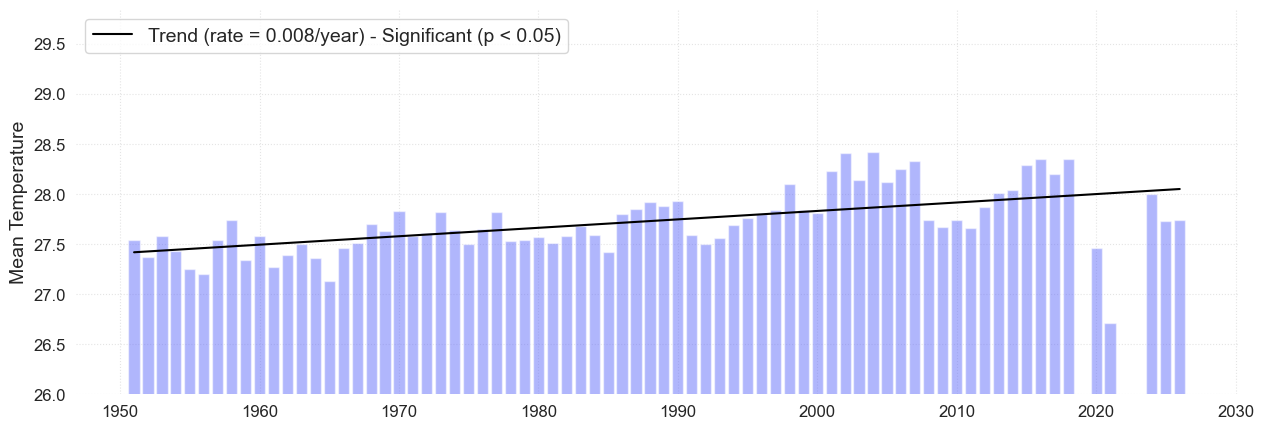

In [12]:
fig, ax, trend = plot_bar_probs(x = st_data.index.year, y = st_data['TMEAN'].values , trendline = True,
               figsize = (15, 5), y_label = f'Mean Temperature', return_trend = True)
ax.set_ylim(26, None)



#### Anomalies vs the reference period

Subtract the 1961–1990 mean so that annual values are expressed as anomalies (°C) relative to the WMO climatology window set in the site configuration.

In [13]:
mean_ref = st_data.loc[ref_start:ref_end].TMEAN.mean()
st_data['TMEAN_ref'] = st_data['TMEAN'] - mean_ref


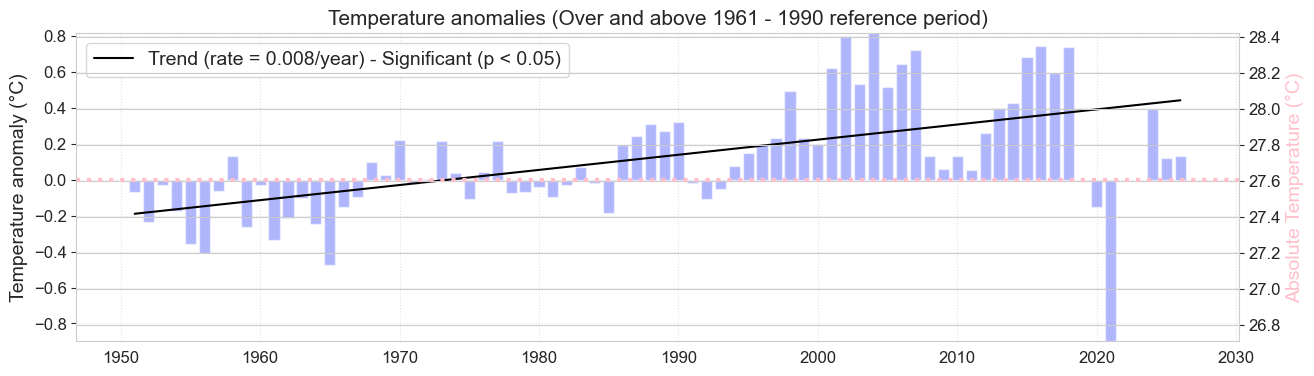

In [14]:
import matplotlib.pyplot as plt
fig, ax, trend = plot_bar_probs(x = st_data.index.year, y = st_data.TMEAN_ref, trendline = True, figsize = [15, 4], return_trend = True)
ax.set_ylim(st_data.TMEAN_ref.min(), st_data.TMEAN_ref.max())
ax2 = ax.twinx()
ax2.axhline(mean_ref, color='pink', linestyle=':', linewidth=3)
ax2.set_ylim(st_data.TMEAN_ref.min() + mean_ref, st_data.TMEAN_ref.max()+ mean_ref)
ax2.set_ylabel('Absolute Temperature (°C)', fontsize = fontsize, color = 'pink')
ax.set_ylabel('Temperature anomaly (°C)', fontsize = fontsize)
plt.title('Temperature anomalies (Over and above 1961 - 1990 reference period)', fontsize = 15);

In [15]:
nevents = 10
top_10 = st_data.sort_values(by='TMEAN_ref', ascending=False).head(nevents)

Bar chart of annual mean temperature anomalies relative to 1961–1990, highlighting the 10 warmest years. Saved as `F2_ST_Annomalies_top10_<site_tag>.png`.

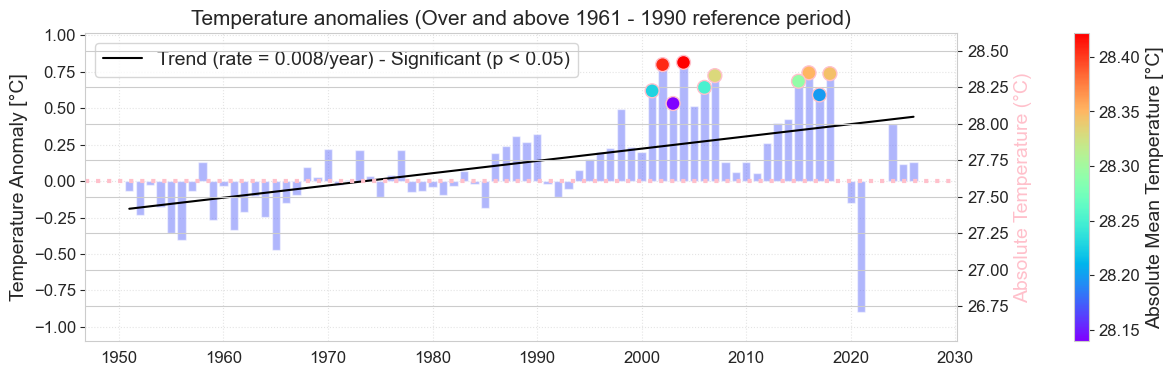

In [16]:
fig, ax, trend = plot_bar_probs(x=st_data.index.year, y=st_data.TMEAN_ref, trendline=True,
                                y_label='Temperature Anomaly [°C]', figsize=[15, 4], return_trend=True)


ax.set_ylim(st_data.TMEAN_ref.min()-.2, st_data.TMEAN_ref.max()+.2)
ax2 = ax.twinx()
ax2.axhline(mean_ref, color='pink', linestyle=':', linewidth=3)
ax2.set_ylim(st_data.TMEAN_ref.min()-.2 + mean_ref, st_data.TMEAN_ref.max() + .2 + mean_ref)
ax2.set_ylabel('Absolute Temperature (°C)', fontsize = fontsize, color = 'pink')

glue("trend_mean", float(trend), display=False)
glue("change_mean", float(trend * len(np.unique(st_data.index.year))), display=False)
glue("top_10_year", float(top_10.sort_index().index.year[0]), display=False)

im = ax2.scatter(top_10.index.year, top_10.TMEAN, 
                c=top_10.TMEAN.values, s=100, ec = 'pink', cmap='rainbow', label='Top 10 warmest years')
plt.title('Temperature anomalies (Over and above 1961 - 1990 reference period)', fontsize=15)
plt.colorbar(im, pad = .1).set_label('Absolute Mean Temperature [°C]', fontsize=fontsize)
plt.savefig(
    site_figures_dir / build_output_filename('F2_ST_Annomalies_top10', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)
glue("trend_fig", fig, display=False)


```{glue:figure} trend_fig
:name: "trend_fig_ST_10"

Annual mean temperature anomalies relative to the 1961–1990 reference period. Overlapping points mark the top 10 warmest years.
```

## ENSO analysis (ONI index)

### Oceanic Niño Index (ONI)

The [Oceanic Niño Index (ONI)](https://origin.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php) monitors El Niño and La Niña events based on sea-surface temperature anomalies in the Niño 3.4 region (3-month running mean).

Monthly mean temperature is joined with ONI to assess how ENSO phases modulate temperature at the station. El Niño years are coloured red, La Niña blue, Neutral grey.

In [17]:

p_data = 'https://psl.noaa.gov/data/correlation/oni.data'

In [18]:
df1 = download_oni_index(p_data)

In [19]:
lims = [-.5, .5]
plot_oni_index_th(df1, lims = lims)

In [20]:
st_data_monthly = st_data_daily.resample('M').mean()
st_data_monthly.index = pd.DatetimeIndex(st_data_monthly.index).to_period('M').to_timestamp() #+ pd.offsets.MonthBegin(1)

In [21]:
df1['tmin'] = st_data_monthly['TMIN']
df1['tmax'] = st_data_monthly['TMAX']
df1['tdiff'] = df1['tmax'] - df1['tmin']
df1['tmean'] = (df1['tmax'] + df1['tmin'])/2
df1['tmean_ref'] = df1['tmean'] - df1.loc[ref_start:ref_end].tmean.mean()
df1['tmean_ref_min'] = df1['tmean'] - df1.groupby(df1.index.year).max().tmean.min()
df1 = add_oni_cat(df1, lims = lims)

### ENSO-modulated temperature anomalies

Annual mean temperature anomalies coloured by ONI category (El Niño / La Niña / Neutral).

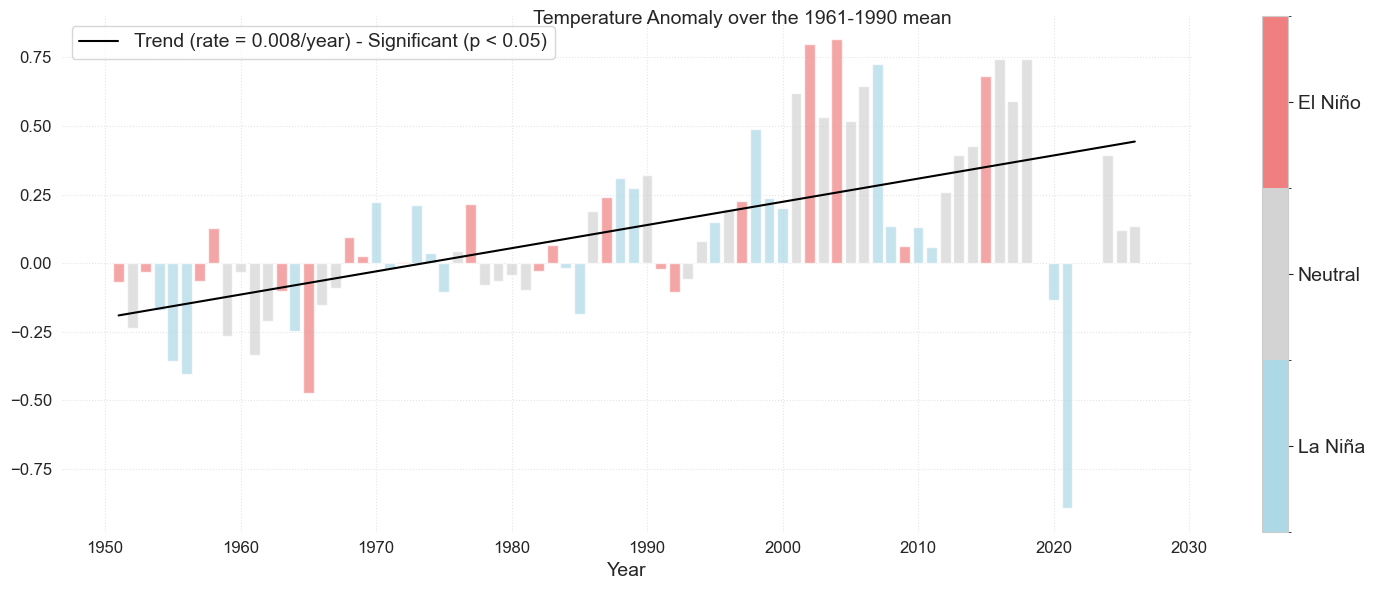

In [22]:
df2 = df1.resample('Y').mean()
fig = plot_bar_probs_ONI(df2, var='tmean_ref');
fig.suptitle('Temperature Anomaly over the 1961-1990 mean', fontsize = fontsize)
plt.savefig(
    site_figures_dir / build_output_filename('F2_ST_Mean', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)

In [23]:
# glue("fig_ninho", fig, display=False)

```{glue:figure} fig_ninho
:name: "fig_ninho"

Annual mean temperature anomalies relative to 1961–1990. Bar colours show El Niño (red), La Niña (blue) and Neutral (grey) phases of ENSO as defined by the Oceanic Niño Index (ONI). A solid black line indicates a statistically significant trend (p < 0.05).
```

In [24]:
df_format = np.round(df1.describe(), 2)

### Summary table and persisted outputs

The final cell builds the summary table and calls `persist_mean_temperature_outputs()` to save:

- `T_mean_annual_<site_tag>.csv`
- `T_mean_summary_table_<site_tag>.csv`
- `T_mean_top10_warmest_years_<site_tag>.csv`
- `T_mean_ONI_annual_<site_tag>.csv`
- `ENSO_temperature_summary_<site_tag>.csv`
- `T_mean_summary_metrics_<site_tag>.json`

In [25]:
from ind_setup.tables import table_temp_11

summary_table = table_temp_11(df2, trend)
persist_mean_temperature_outputs(
    Path('../../../../outputs'),
    site_name, site_lon, site_lat,
    ghcn_station_id, ghcn_station_name, country,
    st_data, df2, top_10, summary_table,
    trend, mean_ref, ref_start, ref_end,
)

Metric,Value
Mean Temperature,27.721
Change in Annual Mean Temperature since 1951,0.600
Rate of Change (°C/year),0.008


PosixPath('../../../../outputs/tables/palau_psw00040309_lat7p337_lon134p477')

## Interpretation and reproducibility notes

- Results apply to the configured station, site or EEZ and should not be generalized without checking spatial representativeness.
- Station coverage, missing observations, relocations and instrument changes can affect apparent variability and trends.
- Linear trends are descriptive unless the notebook explicitly accounts for temporal autocorrelation and other statistical assumptions.
- Confirm the printed source, analysis period, reference period and output paths before using figures or tables in reporting.